In [1]:
import torch
import numpy as np
import pandas as pd
from pyfaidx import Fasta
from Bio import SeqIO

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1708899/ipykernel_240064/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
def one_hot_encode(seq, alphabet="ACGT"):
    """One-hot encode a DNA sequence into (len(seq), 4) numpy array."""
    mapping = {base: i for i, base in enumerate(alphabet)}
    arr = np.zeros((len(seq), len(alphabet)), dtype=np.float32)
    for i, base in enumerate(seq.upper()):
        if base in mapping:
            arr[i, mapping[base]] = 1.0
    return arr

def insert_fragment(background, fragment, insert_pos=None):
    """Insert fragment into background at insert_pos (default: middle)."""
    if insert_pos is None:
        insert_pos = len(background) // 2
    return background[:insert_pos] + fragment + background[insert_pos + len(fragment):]

In [6]:
# Load fragments table
df = pd.read_csv(
    "/scratch1/smaruj/mouse_screening/chr11_69057142_69276687_fragments.tsv", 
    sep="\t"
)

In [7]:
# Load genome
genome = Fasta("/project/fudenber_735/genomes/mm10/mm10.fa")

In [8]:
# Load background fasta (first sequence only)
background_fasta = "/scratch1/smaruj/background_generation/background_sequences_scd30_totvar1300.fasta"
background_record = next(SeqIO.parse(background_fasta, "fasta"))
background_seq = str(background_record.seq)
print(f"Background length: {len(background_seq)}")

Background length: 1310720


In [9]:
# One-hot encode background
background_1hot = one_hot_encode(background_seq)
background_tensor = torch.tensor(background_1hot.T).unsqueeze(0).to(device)  # shape (1, 4, L)

In [10]:
# Baseline prediction
with torch.no_grad():
    baseline_pred = model(background_tensor).cpu()

In [12]:
# -------------------
# Screening
# -------------------

batch_size = 16
scd_scores = []

batch_tensors = []
batch_indices = []

for idx, row in df.iterrows():
    # Fetch fragment from genome
    frag_seq = str(genome[row["chrom"]][row["start"]:row["end"]].seq)
    frag_1hot = one_hot_encode(frag_seq)

    # Insert into background (middle)
    insert_pos = len(background_seq) // 2
    inserted_seq = insert_fragment(background_seq, frag_seq, insert_pos)

    # One-hot encode
    inserted_1hot = one_hot_encode(inserted_seq)
    inserted_tensor = torch.tensor(inserted_1hot.T).unsqueeze(0).to(device)

    # Collect into batch
    batch_tensors.append(inserted_tensor)
    batch_indices.append(idx)

    # Run batch when full
    if len(batch_tensors) == batch_size or idx == len(df) - 1:
        batch_input = torch.cat(batch_tensors, dim=0)  # (B, 4, L)
        with torch.no_grad():
            batch_pred = model(batch_input).cpu()

        # Compute SCD for each
        for i, pred in enumerate(batch_pred):
            diff = pred - baseline_pred.squeeze(0)
            scd = torch.sqrt(torch.sum(diff ** 2)).item()
            scd_scores.append((batch_indices[i], scd))

        # Reset batch
        batch_tensors, batch_indices = [], []

In [13]:
# Add results to dataframe
scd_dict = {i: scd for i, scd in scd_scores}
df["SCD"] = df.index.map(scd_dict)

In [14]:
# Save to TSV
df.to_csv("/scratch1/smaruj/mouse_screening/chr11_screening_results.tsv", sep="\t", index=False)
print("Saved results with SCD.")

Saved results with SCD.


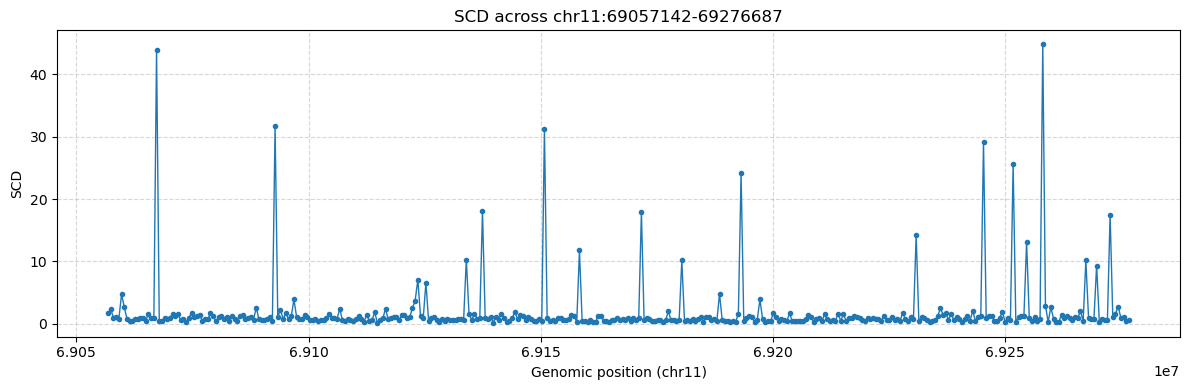

In [15]:
import matplotlib.pyplot as plt

# Use midpoint of fragment for plotting
df["midpoint"] = (df["start"] + df["end"]) // 2

plt.figure(figsize=(12, 4))
plt.plot(df["midpoint"], df["SCD"], marker="o", markersize=3, linewidth=1)
plt.xlabel("Genomic position (chr11)")
plt.ylabel("SCD")
plt.title("SCD across chr11:69057142-69276687")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()